In [1]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress

# import time averaging and mixing functions
from timeAvgFunction import iceTimeAvg
from mixFunction import mixIce

# set plot styles
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 1
mpl.rcParams['lines.linestyle'] = '-'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica']
mpl.rcParams['font.size'] = 9
mpl.rcParams['axes.linewidth'] = .5

# silence warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# load ice data
ice = pd.read_excel("blueIceData.xlsx")
# remove deepest sample which isn't considered in the original paper
ice = ice.iloc[:-1]
# we want to work with just the long snapshot data
ice = ice.loc[ice['SnapshotLong']==1].reset_index(drop=True)

In [3]:
###### CREATE D2H NULL "TRUTH" DATASET
# read in lr04 and also Epica Dome C dD data
lr04 = pd.read_excel("externalData/lisiecki2005-d18o-stack-noaa.xlsx")
edcD = pd.read_excel("externalData/edc3deuttemp2007-noaa.xlsx")
# normalize LR04 in the same age range as EDC
lrCut = lr04.loc[lr04['Age']<= max(edcD.Age/1000)]
lrNorm = -(lr04.d18Ob - np.mean(lrCut.d18Ob))/np.std(lrCut.d18Ob)
# add back stdev from EDC Deuterium, adjust mean to match the group of blue ice measurements younger than 800 ka (EDC span)
lrEDC = lrNorm * np.std(edcD.Deuterium) + np.mean(ice.dDice[ice.Age < 800])
ageLR04 = lr04['Age'].to_numpy()

# uncomment for sanity check plot
# fig = plt.figure(figsize=(4,3))
# ax = fig.add_subplot(1, 1, 1)
# ax.plot(lr04.Age,lrEDC)
# ax.scatter(ice.Age,ice.dDice,20,"red",zorder=5)

In [8]:
###### TIME AVERAGING AND MIXING OF D2H
dDSim = iceTimeAvg(ice.Age, ice.AgeErrA, 200, ageLR04,lrEDC,1000)
# mix - sample step is still 10 cm as with CO2
sampStep = 0.1
# do a low and high mixing scenario, high is equivalent to CO2 mixing value of 70 cm
minMix = 0.3
maxMix = 0.75
dmid = ice[['TopDepth', 'BottomDepth']].mean(axis=1)
_, _, _, dDmixMin = mixIce(dmid,sampStep,dDSim,minMix)
_, _, _, dDmixMax = mixIce(dmid,sampStep,dDSim,maxMix)

In [9]:
###### COMPARE STATISTICS FOR D2H DATA AND SIMULATIONS
# first the variance
dDpres = ~np.isnan(ice.dDice)
compSet = dDmixMin
# uncomment to check the 70 cm simulation. Variance is too low.
# compSet = dDmixMax
icevar = np.var(ice.dDice[dDpres],ddof=1)
icevarerr = np.sqrt((2 * (icevar**2)) / (len(ice.dDice[dDpres]) - 1))
simvar = np.var(compSet[dDpres,:],ddof=1)
print(f"Data Variance: {icevar:.0f} ± {icevarerr:.0f}")
print(f"Simulated Variance: {simvar:.0f}")
# RMSE
rmse = np.sqrt(np.mean(np.square(ice.dDice[dDpres] - np.mean(compSet[dDpres,:],1))))
print(f"RMSE: {rmse:.1f} per mil")
# correlation
corrmatrix = np.corrcoef(ice.dDice[dDpres],np.mean(compSet[dDpres,:],1))
print(f"Correlation between data and simulation: {corrmatrix[0, 1]:.2f}")

Data Variance: 66 ± 13
Simulated Variance: 68
RMSE: 5.6 per mil
Correlation between data and simulation: 0.76


In [11]:
###### CREATE NULL TRUTH DATASET FOR MOT
# for this we will first forward model from a "truth" MOT record based on scaling LR04 to EDC MOT (from Kr/N2)
# read in lr04 and also EDC dD data
edcMOT = pd.read_excel("externalData/edc2021noblegastemp.xlsx")
# normalize LR04 in the same age range as EDC
lrCut = lr04.loc[lr04['Age']<= max(edcMOT.Age)]
lrNorm = -(lr04.d18Ob - np.mean(lrCut.d18Ob))/np.std(lrCut.d18Ob)
# add back stdev from EDC Deuterium, adjust mean to match the youngest group of MOT measurements
lrMOT = lrNorm * np.std(edcMOT.MOTKrN2) + np.mean(ice.MOT[ice.Age < 800])
# let's also try a null hypothesis with Clark et al 2024
gsst = pd.read_excel("externalData/Clark2024Temp.xlsx")
gsstCut = gsst.loc[gsst['Age']*1000 <= max(edcMOT.Age)]
sstNorm = (gsst.GSST - np.mean(gsstCut.GSST))/np.std(gsstCut.GSST)
sstMOT = sstNorm * np.std(edcMOT.MOTKrN2) + np.mean(ice.MOT[ice.Age < 800])
sstAge = gsst['Age']*1000

In [12]:
######## TIME AVERAGING AND MIXING OF MOT
# time average
MOTSim = iceTimeAvg(ice.Age, ice.AgeErrA, 200, ageLR04, lrMOT, 1000)
MOTSimSST = iceTimeAvg(ice.Age, ice.AgeErrA, 200, sstAge,sstMOT,1000)
# MOT mixing depth
minMix2 = 0.3
# mixing with scaled LR04
_, _, _, MOTmixMin = mixIce(dmid,sampStep,MOTSim,minMix2)
_, _, _, MOTmixMax = mixIce(dmid,sampStep,MOTSim,maxMix)
# mixing with scaled Clark24
_, _, _, MOTmixSSTMin = mixIce(dmid,sampStep,MOTSimSST,minMix2)
_, _, _, MOTmixSSTMax = mixIce(dmid,sampStep,MOTSimSST,maxMix)
# in the case of MOT we need to add an additional error term associated with inference from Xe/Kr
# we can use the relative error column in the provided data set as a 1-sigma error
MOTpres = ~np.isnan(ice.MOT)
MOTdats = MOTmixMin[MOTpres,:]
MOTdats6 = MOTmixMax[MOTpres,:]
MOTsst3 = MOTmixSSTMin[MOTpres,:]
MOTsst6 = MOTmixSSTMax[MOTpres,:]
# MC sampling of this err
N = 1000
M = len(MOTdats)
MOTerrs = ice.MOTErr[MOTpres].to_numpy()
MOTrndE = np.random.normal(np.zeros(M),MOTerrs,size=(N,M)).T
# add error to final ensembles
MOTMin = MOTdats + MOTrndE
MOTMax = MOTdats6 + MOTrndE
MOTSSTMin = MOTsst3 + MOTrndE
MOTSSTMax = MOTsst6 + MOTrndE

In [13]:
###### COMPARE STATISTICS FOR MOT DATA AND SIMULATIONS
MOTpres = (~np.isnan(ice.MOT))
compSet = MOTMin
icevar = np.var(ice.MOT[MOTpres],ddof=1)
icevarerr = np.sqrt((2 * (icevar**2)) / (len(ice.MOT[MOTpres]) - 1))
simvar = np.var(compSet,ddof=1)
print(f"Data Variance: {icevar:.2f} ± {icevarerr:.2f}")
print(f"Simulated Variance: {simvar:.2f}")
# RMSE
rmse = np.sqrt(np.mean(np.square(ice.MOT[MOTpres] - np.mean(compSet,1))))
print(f"RMSE: {rmse:.1f} ˚C")
# correlation
corrmatrix = np.corrcoef(ice.MOT[MOTpres],np.mean(compSet,1))
print(f"Correlation between data and simulation: {corrmatrix[0, 1]:.2f}")

Data Variance: 0.63 ± 0.12
Simulated Variance: 0.62
RMSE: 0.5 ˚C
Correlation between data and simulation: 0.86


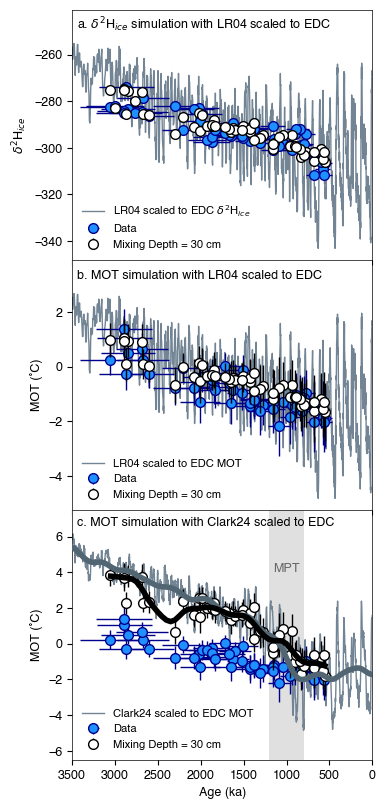

In [14]:
########## FIGURE WITH D2H AND MOT SIMULATIONS
dDpres = ~np.isnan(ice.dDice)
MOTpres = ~np.isnan(ice.MOT)
# start figure
fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(3,7.5))
############# d2H
# null and data
ax0.plot(lr04.Age,lrEDC,color="xkcd:steel", label="LR04 scaled to EDC $\delta^2$H$_{ice}$")
ax0.errorbar(ice.Age,ice.dDice,xerr=ice.AgeErrA,markerfacecolor="dodgerblue",marker='o',markersize=7,
             linestyle='None',zorder=5,markeredgecolor="darkblue", color="darkblue", label="Data")
# uncomment to plot a high mixing scenario.
# ax0.errorbar(ice.Age[dDpres],np.mean(dDmixMax[dDpres,:],1),yerr=np.std(dDmixMax[dDpres,:],1),color="black",marker='o',linestyle='None',
#         markeredgecolor="black",markerfacecolor="silver",markersize=7,label=f"Mixing Depth = {maxMix*100:.0f} cm",zorder=12)
# best match mixing scenario.
ax0.errorbar(ice.Age[dDpres],np.mean(dDmixMin[dDpres,:],1),yerr=np.std(dDmixMin[dDpres,:],1),color="black",marker='o',linestyle='None',
        markeredgecolor="black",markerfacecolor="white",markersize=7,label=f"Mixing Depth = {minMix*100:.0f} cm",zorder=12)
ax0.set_xlim(0,3500)
ax0.set_ylabel("$\delta^2$H$_{ice}$")
ax0.text(3450,-249,"a. $\delta^2$H$_{ice}$ simulation with LR04 scaled to EDC",fontsize=9)
ax0.legend(loc='lower left',frameon=False, fontsize=8)
############## MOT
# null and data
ax1.plot(lr04.Age,lrMOT,color="xkcd:steel", label="LR04 scaled to EDC MOT")
ax1.errorbar(ice.Age[MOTpres],ice.MOT[MOTpres],yerr=ice.MOTErr[MOTpres]*2,xerr=ice.AgeErrA[MOTpres],color="darkblue",marker='o',linestyle='None',
            markersize=7,zorder=5,markerfacecolor="dodgerblue", label="Data")
# uncomment to plot a high mixing scenario.
# ax1.errorbar(ice.Age[MOTpres],np.mean(MOTMax,1),yerr=np.std(MOTMax,1)*2,color="black",marker='o',linestyle='None',
#         markeredgecolor="black",markerfacecolor="silver",markersize=7,label=f"Mixing Depth = {maxMix*100:.0f} cm",zorder=12)
ax1.errorbar(ice.Age[MOTpres],np.mean(MOTMin,1),yerr=np.std(MOTMin,1)*2,color="black",marker='o',linestyle='None',
        markeredgecolor="black",markerfacecolor="white",markersize=7,label=f"Mixing Depth = {minMix2*100:.0f} cm",zorder=12)
ax1.set_xlim(0,3500)
ax1.legend(loc='lower left',frameon=False, fontsize=8)
ax1.set_xlabel("Age (ka)")
ax1.set_ylabel("MOT (˚C)")
ax1.text(3450,3.2,"b. MOT simulation with LR04 scaled to EDC",fontsize=9)
ax1.invert_xaxis()
############### MOT with Clark SST
# null
ax2.plot(sstAge,sstMOT,color="xkcd:steel", label="Clark24 scaled to EDC MOT")
# put in MPT rectangle
ylims = (-6.5,7.5)
ax2.set_ylim(ylims)
xStart = 800
yStart = ylims[0]
rWidth = 400
rHeight = ylims[1]-ylims[0]
rect = patches.Rectangle((xStart, yStart), rWidth, rHeight, edgecolor="None", facecolor="lightgray", alpha = 0.7, zorder=0)
ax2.add_patch(rect)
ax2.text(1160,4,"MPT",color="dimgray")
#
ax2.errorbar(ice.Age[MOTpres],ice.MOT[MOTpres],yerr=ice.MOTErr[MOTpres]*2,xerr=ice.AgeErrA[MOTpres],color="darkblue",marker='o',linestyle='None',
            markersize=7,zorder=5,markerfacecolor="dodgerblue", label="Data")
# uncomment to plot high mixing scenario.
# ax2.errorbar(ice.Age[MOTpres],np.mean(MOTSSTMax,1),yerr=np.std(MOTSSTMax,1)*2,color="black",marker='o',linestyle='None',
#         markeredgecolor="black",markerfacecolor="silver",markersize=7,label=f"Mixing Depth = {maxMix*100:.0f} cm",zorder=12)
ax2.errorbar(ice.Age[MOTpres],np.mean(MOTSSTMin,1),yerr=np.std(MOTSSTMin,1)*2,color="black",marker='o',linestyle='None',
        markeredgecolor="black",markerfacecolor="white",markersize=7,label=f"Mixing Depth = {minMix2*100:.0f} cm",zorder=12)
## add a gaussian smooth to highlight MPT
iAge = ice.Age[MOTpres].reset_index(drop=True).to_numpy()
SortIndex = np.argsort(iAge)
AgeSort = iAge[SortIndex]
MOTSort = np.mean(MOTSSTMin[SortIndex,:],1)
x_target = np.arange(AgeSort.min(), AgeSort.max(), 50)
m_interp = np.interp(x_target,AgeSort,MOTSort)
m_smooth = gaussian_filter1d(m_interp,sigma=10/6)#3
ax2.plot(x_target,m_smooth,color="black",linewidth=4,zorder=20)
#gaussian on Clark
c_smooth = gaussian_filter1d(sstMOT,sigma=500/6)#150
ax2.plot(sstAge,c_smooth,color="xkcd:slate",linewidth=4,zorder=18)
##
ax2.set_xlim(0,3500)
ax2.legend(loc='lower left',frameon=False, fontsize=8)
ax2.set_xlabel("Age (ka)")
ax2.set_ylabel("MOT (˚C)")
ax2.text(3450,6.6,"c. MOT simulation with Clark24 scaled to EDC",fontsize=9)
ax2.invert_xaxis()
# adjust spacing
fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)
# print to pdf
fig.savefig("outputFigures/dDandMOT.pdf", bbox_inches="tight")

In [15]:
######## d2H trend comparison
# Null LR04
cTime = 3000
idx1 = ageLR04 < cTime
nullAge = ageLR04[idx1]/1000
nullIso = lrEDC[idx1]
# dD
dAge = ice.Age[dDpres]/1000
dDats = ice.dDice[dDpres]
dTime = np.mean(dDSim[dDpres,:],axis=1)
dSim = np.mean(dDmixMin[dDpres,:],axis=1)

datout = linregress(dAge,dDats)
tout = linregress(dAge,dTime)
simout = linregress(dAge,dSim)
nullout = linregress(nullAge,nullIso)

print(f"Data Slope: {datout.slope:.0f} ± {datout.stderr*2:.0f}")
print(f"Data p-value: {datout.pvalue:.3f}")
print(f"Data Correlation: {datout.rvalue:.2f}")

print(f"Simulated Slope: {simout.slope:.0f} ± {simout.stderr*2:.0f}")
print(f"Simulated p-value: {simout.pvalue:.3f}")
print(f"Simulated Correlation: {simout.rvalue:.2f}")

print(f"Time Avg Slope: {tout.slope:.0f} ± {simout.stderr*2:.0f}")
print(f"Time Avg p-value: {tout.pvalue:.3f}")
print(f"Time Avg Correlation: {tout.rvalue:.2f}")

print(f"Null Avg Slope: {nullout.slope:.0f} ± {simout.stderr*2:.0f}")
print(f"Null Avg p-value: {nullout.pvalue:.3f}")
print(f"Null Avg Correlation: {nullout.rvalue:.2f}")

Data Slope: 9 ± 2
Data p-value: 0.000
Data Correlation: 0.85
Simulated Slope: 10 ± 1
Simulated p-value: 0.000
Simulated Correlation: 0.93
Time Avg Slope: 14 ± 1
Time Avg p-value: 0.000
Time Avg Correlation: 0.99
Null Avg Slope: 12 ± 1
Null Avg p-value: 0.000
Null Avg Correlation: 0.59


In [16]:
######## MOT trend comparison
# Null MOT LR04
nullMOT = lrMOT[idx1]

# MOT
mAge = ice.Age[MOTpres]/1000
mDats = ice.MOT[MOTpres]
mTimeLR04 = np.mean(MOTSim[MOTpres,:],axis=1)
mSimLR04 = np.mean(MOTMin,axis=1)

datout = linregress(mAge,mDats)
tout = linregress(mAge,mTimeLR04)
simout = linregress(mAge,mSimLR04)
nullout = linregress(nullAge,nullMOT)

print(f"Data Slope: {datout.slope:.1f} ± {datout.stderr*2:.1f}")
print(f"Data p-value: {datout.pvalue:.3f}")
print(f"Data Correlation: {datout.rvalue:.2f}")

print(f"Simulated Slope: {simout.slope:.1f} ± {simout.stderr*2:.1f}")
print(f"Simulated p-value: {simout.pvalue:.3f}")
print(f"Simulated Correlation: {simout.rvalue:.2f}")

print(f"Time Avg Slope: {tout.slope:.1f} ± {simout.stderr*2:.1f}")
print(f"Time Avg p-value: {tout.pvalue:.3f}")
print(f"Time Avg Correlation: {tout.rvalue:.2f}")

print(f"Null Avg Slope: {nullout.slope:.1f} ± {simout.stderr*2:.1f}")
print(f"Null Avg p-value: {nullout.pvalue:.3f}")
print(f"Null Avg Correlation: {nullout.rvalue:.2f}")

Data Slope: 0.9 ± 0.2
Data p-value: 0.000
Data Correlation: 0.85
Simulated Slope: 0.9 ± 0.1
Simulated p-value: 0.000
Simulated Correlation: 0.93
Time Avg Slope: 1.2 ± 0.1
Time Avg p-value: 0.000
Time Avg Correlation: 0.99
Null Avg Slope: 1.0 ± 0.1
Null Avg p-value: 0.000
Null Avg Correlation: 0.59
